In [32]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
import scipy.ndimage

os.environ['VXM_BACKEND'] = 'pytorch'

In [33]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [34]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [38]:
# 画像を読み込み
x_train = np.load('Data/TrainData_NoBed.npz')['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))

print('Resized train vol_shape:', x_train.shape[1:])
print('Resized train shape:', x_train.shape)

Resized train vol_shape: (128, 256, 256)
Resized train shape: (400, 128, 256, 256)


In [39]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [40]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 128, 256, 256])
Fixed Images Shape: torch.Size([2, 1, 128, 256, 256])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 128, 256, 256])
Zero Gradient Shape: (2, 128, 256, 256, 3)


In [41]:
mse_loss = vxm.losses.MSE().loss
grad_loss = vxm.losses.Grad('l2').loss

def total_loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    grad = grad_loss(y_true, y_pred)
    return mse + 0.01 * grad, mse, grad
#     return mse_loss(y_true, y_pred)

def MSE_Loss(y_true, y_pred):
    y_true = y_true.to(device)
    y_pred = y_pred.to(device)
    mse = mse_loss(y_true, y_pred)
    return mse

def lncc_loss(I, J, window=9, eps=1e-5):
    # I, J: (B, 1, D, H, W)
    padding = window // 2
    weight = torch.ones(1, 1, window, window, window, device=I.device)

    I2 = I * I
    J2 = J * J
    IJ = I * J

    I_sum = F.conv3d(I, weight, padding=padding)
    J_sum = F.conv3d(J, weight, padding=padding)
    I2_sum = F.conv3d(I2, weight, padding=padding)
    J2_sum = F.conv3d(J2, weight, padding=padding)
    IJ_sum = F.conv3d(IJ, weight, padding=padding)

    win_size = window ** 3
    u_I = I_sum / win_size
    u_J = J_sum / win_size

    cross = IJ_sum - u_J * I_sum - u_I * J_sum + u_I * u_J * win_size
    I_var = I2_sum - 2 * u_I * I_sum + u_I * u_I * win_size
    J_var = J2_sum - 2 * u_J * J_sum + u_J * u_J * win_size

    lncc = cross * cross / (I_var * J_var + eps)
    return -torch.mean(lncc)  # maximize LNCC → minimize -LNCC

In [42]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64, 64],
    [64, 64, 64, 64, 64, 32, 16, 16]
]


In [43]:
model3D = vxm.networks.VxmDense_128_256_128((128, 256, 256), nb_features, int_steps=0)
model3D.to(device)
optimizer = optim.Adam(model3D.parameters(), lr=1e-4)

transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)
transformer256 = vxm.layers.SpatialTransformer((128, 256, 256)).to(device)

[64, 128, 128]


In [44]:
import torch

def haar_wavelet_3d(x):
    """
    x: torch.Tensor (B,1,D,H,W)
    return: torch.Tensor (B,8,D/2,H/2,W/2)
    """

    # 偶数・奇数インデックス
    x000 = x[:, :, 0::2, 0::2, 0::2]
    x001 = x[:, :, 0::2, 0::2, 1::2]
    x010 = x[:, :, 0::2, 1::2, 0::2]
    x011 = x[:, :, 0::2, 1::2, 1::2]
    x100 = x[:, :, 1::2, 0::2, 0::2]
    x101 = x[:, :, 1::2, 0::2, 1::2]
    x110 = x[:, :, 1::2, 1::2, 0::2]
    x111 = x[:, :, 1::2, 1::2, 1::2]

    # Haar 係数（正規化つき）
    LLL = (x000 + x001 + x010 + x011 + x100 + x101 + x110 + x111) / 8
    LLH = (x000 - x001 + x010 - x011 + x100 - x101 + x110 - x111) / 8
    LHL = (x000 + x001 - x010 - x011 + x100 + x101 - x110 - x111) / 8
    LHH = (x000 - x001 - x010 + x011 + x100 - x101 - x110 + x111) / 8
    HLL = (x000 + x001 + x010 + x011 - x100 - x101 - x110 - x111) / 8
    HLH = (x000 - x001 + x010 - x011 - x100 + x101 - x110 + x111) / 8
    HHL = (x000 + x001 - x010 - x011 - x100 - x101 + x110 + x111) / 8
    HHH = (x000 - x001 - x010 + x011 - x100 + x101 + x110 - x111) / 8

    return torch.cat(
        [LLL, LLH, LHL, LHH, HLL, HLH, HHL, HHH],
        dim=1
    )

def inverse_haar_wavelet_3d(x):
    """
    x: torch.Tensor (B,8,D/2,H/2,W/2)
    return: torch.Tensor (B,1,D,H,W)
    """

    B, _, D, H, W = x.shape
    device = x.device

    LLL, LLH, LHL, LHH, HLL, HLH, HHL, HHH = torch.chunk(x, 8, dim=1)

    out = torch.zeros(
        (B, 1, D * 2, H * 2, W * 2),
        device=device,
        dtype=x.dtype
    )

    out[:, :, 0::2, 0::2, 0::2] = (
        LLL + LLH + LHL + LHH + HLL + HLH + HHL + HHH
    )
    out[:, :, 0::2, 0::2, 1::2] = (
        LLL - LLH + LHL - LHH + HLL - HLH + HHL - HHH
    )
    out[:, :, 0::2, 1::2, 0::2] = (
        LLL + LLH - LHL - LHH + HLL + HLH - HHL - HHH
    )
    out[:, :, 0::2, 1::2, 1::2] = (
        LLL - LLH - LHL + LHH + HLL - HLH - HHL + HHH
    )
    out[:, :, 1::2, 0::2, 0::2] = (
        LLL + LLH + LHL + LHH - HLL - HLH - HHL - HHH
    )
    out[:, :, 1::2, 0::2, 1::2] = (
        LLL - LLH + LHL - LHH - HLL + HLH - HHL + HHH
    )
    out[:, :, 1::2, 1::2, 0::2] = (
        LLL + LLH - LHL - LHH - HLL - HLH + HHL + HHH
    )
    out[:, :, 1::2, 1::2, 1::2] = (
        LLL - LLH - LHL + LHH - HLL + HLH + HHL - HHH
    )

    return out


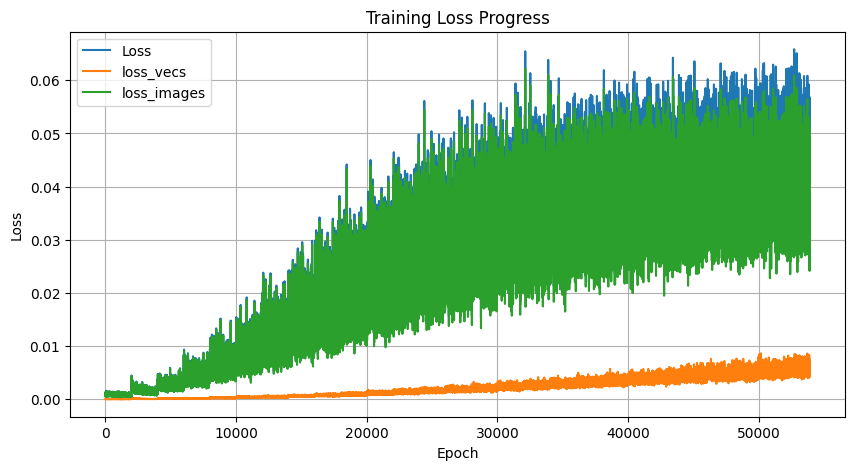

Epoch 53891/80000, Loss: 0.0334, loss_vec: 0.0058, loss_image: 0.0276, Shift Range: ±27 pixels
Epoch 53892/80000, Loss: 0.0384, loss_vec: 0.0055, loss_image: 0.0329, Shift Range: ±27 pixels
Epoch 53893/80000, Loss: 0.0454, loss_vec: 0.0051, loss_image: 0.0403, Shift Range: ±27 pixels
Epoch 53894/80000, Loss: 0.0443, loss_vec: 0.0053, loss_image: 0.0390, Shift Range: ±27 pixels
Epoch 53895/80000, Loss: 0.0559, loss_vec: 0.0063, loss_image: 0.0496, Shift Range: ±27 pixels
Epoch 53896/80000, Loss: 0.0381, loss_vec: 0.0069, loss_image: 0.0312, Shift Range: ±27 pixels
Epoch 53897/80000, Loss: 0.0418, loss_vec: 0.0072, loss_image: 0.0346, Shift Range: ±27 pixels
Epoch 53898/80000, Loss: 0.0375, loss_vec: 0.0066, loss_image: 0.0309, Shift Range: ±27 pixels
Epoch 53899/80000, Loss: 0.0398, loss_vec: 0.0069, loss_image: 0.0329, Shift Range: ±27 pixels
Epoch 53900/80000, Loss: 0.0512, loss_vec: 0.0072, loss_image: 0.0440, Shift Range: ±27 pixels


In [ ]:
# NotdecoderHight
from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

# 3D ガウシアンフィルタを適用する関数
def gaussian_smooth_3d(tensor, kernel_size=5, sigma=1.0):
    """ 3D ガウシアンフィルタで displacement field をスムージング """
    # 3D Gaussian Kernel の作成
    from scipy.ndimage import gaussian_filter
    tensor_np = tensor.cpu().numpy()
    smoothed_np = gaussian_filter(tensor_np, sigma=[0, 0, sigma, sigma, sigma])  # チャネル方向にはフィルタ適用しない
    return torch.tensor(smoothed_np, dtype=torch.float32, device=tensor.device)


# エポック数と最小ロスの設定
epochs = 80000
best_loss = float('inf')
shift_range = 1

# ロスや他のメトリクスを記録するリスト
losses = []
loss_vecs = []
loss_images = []
loss_hightVecs = []
for epoch in tqdm(range(epochs)):
    # 100エポックごとにshift_rangeを増やす
    if epoch % 2000 == 0 and epoch > 0:
        shift_range += 1
        print(f"Epoch {epoch}: Increasing shift range to ±{shift_range} pixels.")

    # 学習データのバッチを取得
    train_batch, _ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32).to(device)

    # 画像サイズを設定
    B, D, H, W = 2, 8, 16, 16  # バッチサイズと画像の次元

    # displacement_field をボクセルごとにランダムに作成
    displacement_field = (torch.rand((B, 3, D, H, W), dtype=torch.float32) * 2 - 1) * shift_range
    displacement_field = displacement_field.to(device)

    # 3D Gaussian Smoothing を適用
    displacement_field = gaussian_smooth_3d(displacement_field, sigma=2.0)
    displacement_field = torch.nn.functional.interpolate(displacement_field, size=(128,256,256), mode='trilinear', align_corners=False)
    displacement_field128 = torch.nn.functional.interpolate(displacement_field, size=(64,128,128), mode='trilinear', align_corners=False)

    # 位置をずらした画像を生成
    moving_images2 = transformer256(moving_images, displacement_field)

    # Wavelet 変換（前処理）
    moving_w = haar_wavelet_3d(moving_images)  # (B,8,D/2,H/2,W/2)
    moving_images2_w  = haar_wavelet_3d(moving_images2)   # (B,8,D/2,H/2,W/2)
    
    # device に戻す
    moving_w = moving_w.to(device)
    moving_images2_w  = moving_images2_w.to(device)

    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    Vec = model3D(moving_w, moving_images2_w)

    # --- 各 Wavelet 成分を変形 ---
    moving_LLL = transformer(moving_w[:, 0:1], Vec)
    moving_LLH = transformer(moving_w[:, 1:2], Vec)
    moving_LHL = transformer(moving_w[:, 2:3], Vec)
    moving_LHH = transformer(moving_w[:, 3:4], Vec)
    moving_HLL = transformer(moving_w[:, 4:5], Vec)
    moving_HLH = transformer(moving_w[:, 5:6], Vec)
    moving_HHL = transformer(moving_w[:, 6:7], Vec)
    moving_HHH = transformer(moving_w[:, 7:8], Vec)
    
    moving_warped = torch.cat(
        [
            moving_LLL, moving_LLH, moving_LHL, moving_LHH,
            moving_HLL, moving_HLH, moving_HHL, moving_HHH
        ],
        dim=1
    )  # (B,8,D/2,H/2,W/2)
    
    # 逆Wavelet
    transformed_image = inverse_haar_wavelet_3d(moving_warped)
    
    transformed_image = transformed_image.to(device) 

    # 損失を計算
    loss_vec = MSE_Loss(displacement_field128, Vec) * 0.01
    loss_image = MSE_Loss(moving_images2, transformed_image) * 100
    
    loss = loss_vec + loss_image

    # 逆伝播
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        torch.save(
            model3D.state_dict(),
            f'            .pth'
        )
        
    losses.append(loss.cpu().item())
    loss_vecs.append(loss_vec.cpu().item())
    loss_images.append(loss_image.cpu().item())

    # 100エポックごとにグラフを更新
    if epoch % 10 == 0:
        clear_output(wait=True)  # 出力をリフレッシュ
        plt.figure(figsize=(10,5))
        plt.plot(losses, label='Loss')
        plt.plot(loss_vecs, label='loss_vecs')
        plt.plot(loss_images, label='loss_images')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Progress")
        plt.legend()
        plt.grid(True)
        plt.show()
    
    # エポックごとのロスの表示
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, loss_vec: {loss_vec:.4f}, loss_image: {loss_image:.4f}, Shift Range: ±{shift_range} pixels")


In [ ]:
from tqdm.notebook import tqdm

model3D = vxm.networks.VxmDense_128_256_128((128, 256, 256), nb_features, int_steps=0)
model3D.load_state_dict(torch.load('             ', map_location=device))
model3D.to(device)
optimizer = optim.Adam(model3D.parameters(), lr=1e-4)

# エポック数と最小ロスの設定
epochs = 30000

# ロスや他のメトリクスを記録するリスト
losses = []
mses = []
grads = []

for epoch in tqdm(range(epochs)):

    # 学習データのバッチを取得
    train_batch, _ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    # Wavelet 変換（前処理）
    moving_w = haar_wavelet_3d(moving_images)  # (B,8,D/2,H/2,W/2)
    fixed_w  = haar_wavelet_3d(fixed_images)   # (B,8,D/2,H/2,W/2)
    
    # device に戻す
    moving_w = moving_w.to(device)
    fixed_w  = fixed_w.to(device)

    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    Vec = model3D(moving_w, fixed_w)

    # --- 各 Wavelet 成分を変形 ---
    moving_LLL = transformer(moving_w[:, 0:1], Vec)
    moving_LLH = transformer(moving_w[:, 1:2], Vec)
    moving_LHL = transformer(moving_w[:, 2:3], Vec)
    moving_LHH = transformer(moving_w[:, 3:4], Vec)
    moving_HLL = transformer(moving_w[:, 4:5], Vec)
    moving_HLH = transformer(moving_w[:, 5:6], Vec)
    moving_HHL = transformer(moving_w[:, 6:7], Vec)
    moving_HHH = transformer(moving_w[:, 7:8], Vec)
    
    moving_warped = torch.cat(
        [
            moving_LLL, moving_LLH, moving_LHL, moving_LHH,
            moving_HLL, moving_HLH, moving_HHL, moving_HHH
        ],
        dim=1
    )  # (B,8,D/2,H/2,W/2)
    
    # 逆Wavelet
    transformed_image = inverse_haar_wavelet_3d(moving_warped)
    
    transformed_image = transformed_image.to(device)    
    # 損失を計算
    loss = MSE_Loss(fixed_images, transformed_image)

    # 逆伝播
    loss.backward()
    optimizer.step()

    # モデルを保存
    torch.save(model3D.state_dict(), '         .pth')

    # エポックごとのロスを保存
    losses.append(loss.cpu().item())
    
    # エポックごとのロスの表示
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")
